# 🏥 HCC Detection with ResNet-50 Encoder
## 2D Slice-Based Liver & Tumor Segmentation

**Based on:** liver-segmentation-resnet-50.ipynb approach  
**Data:** Downloaded via kagglehub from Kaggle datasets

**Features:**
- 🔬 ResNet-50 encoder with U-Net decoder
- 📊 2D slice segmentation (like the original)
- 🎯 DICOM windowing for liver visualization
- 📋 Cancer detection with visualizations
- 📥 Auto-downloads datasets from Kaggle

In [ ]:
# ============================================================================
# CELL 1: INSTALL DEPENDENCIES
# ============================================================================
import subprocess
import sys

packages = ['nibabel', 'scikit-image', 'plotly', 'tqdm', 'torchvision', 'kagglehub']
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print("✅ Dependencies ready!")

✅ Dependencies ready!


In [2]:
# ============================================================================
# CELL 2: IMPORTS
# ============================================================================
import os
import glob
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models

import nibabel as nib
from scipy import ndimage
from scipy.ndimage import zoom, label as scipy_label, center_of_mass, find_objects
from skimage import measure
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

torch.manual_seed(42)
np.random.seed(42)
print("\n✅ All imports loaded!")

c:\Users\asus\Downloads\HEPTACELLULAR CARCINOMA DETECTION\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🖥️ Device: cuda
🎮 GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
💾 VRAM: 4.29 GB

✅ All imports loaded!


In [3]:
# ============================================================================
# CELL 3: CONFIGURATION (LOCAL PATHS)
# ============================================================================
@dataclass
class Config:
    """Local configuration - no Kaggle paths!"""
    
    # LOCAL workspace
    workspace: str = r'c:\Users\asus\Downloads\HEPTACELLULAR CARCINOMA DETECTION'
    output_dir: str = r'c:\Users\asus\Downloads\HEPTACELLULAR CARCINOMA DETECTION\output'
    model_dir: str = r'c:\Users\asus\Downloads\HEPTACELLULAR CARCINOMA DETECTION\models'
    slice_dir: str = r'c:\Users\asus\Downloads\HEPTACELLULAR CARCINOMA DETECTION\slices'
    
    # DICOM windowing (same as original notebook)
    liver_window: Tuple[int, int] = (150, 30)   # (width, level)
    custom_window: Tuple[int, int] = (200, 60)
    
    # Training
    image_size: int = 256  # Larger than original's 128 for better quality
    batch_size: int = 8
    num_workers: int = 0  # Windows compatibility
    max_epochs: int = 30
    learning_rate: float = 1e-4
    
    # Classes (same as original)
    num_classes: int = 3
    class_names: List[str] = field(default_factory=lambda: ['Background', 'Liver', 'Tumor'])
    class_colors: List[str] = field(default_factory=lambda: ['#1f1f1f', '#3498db', '#e74c3c'])
    
    # Diagnostic
    malignancy_threshold: float = 0.10
    
    def __post_init__(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.model_dir, exist_ok=True)
        os.makedirs(self.slice_dir, exist_ok=True)

config = Config()
print("⚙️ Configuration loaded!")
print(f"   Workspace: {config.workspace}")

⚙️ Configuration loaded!
   Workspace: c:\Users\asus\Downloads\HEPTACELLULAR CARCINOMA DETECTION


In [4]:
# ============================================================================
# CELL 4: DICOM WINDOWING (Same approach as original)
# ============================================================================

def apply_window(image: np.ndarray, window: Tuple[int, int]) -> np.ndarray:
    """
    Apply DICOM windowing to CT image.
    Same as the @patch windowed function in the original notebook.
    
    Args:
        image: CT image in HU
        window: (width, level) tuple
    Returns:
        Windowed image normalized to [0, 1]
    """
    w, l = window
    px_min = l - w // 2
    px_max = l + w // 2
    img = np.clip(image, px_min, px_max)
    return (img - px_min) / (px_max - px_min)


def to_multichannel(image: np.ndarray, windows: List[Tuple[int, int]]) -> np.ndarray:
    """
    Convert single-channel CT to multi-channel using different windows.
    Same as the to_nchan function in the original notebook.
    
    Returns: (C, H, W) array with C = len(windows)
    """
    channels = [apply_window(image, win) for win in windows]
    return np.stack(channels, axis=0).astype(np.float32)


# Define windows (same as original)
DICOM_WINDOWS = {
    'brain': (80, 40),
    'subdural': (254, 100),
    'stroke': (8, 32),
    'brain_bone': (2800, 600),
    'brain_soft': (375, 40),
    'lungs': (1500, -600),
    'mediastinum': (350, 50),
    'abdomen_soft': (400, 50),
    'liver': (150, 30),
    'spine_soft': (250, 50),
    'spine_bone': (1800, 400),
    'custom': (200, 60)
}

print("✅ DICOM windowing functions defined!")
print(f"   Using windows: liver {DICOM_WINDOWS['liver']}, custom {DICOM_WINDOWS['custom']}")

✅ DICOM windowing functions defined!
   Using windows: liver (150, 30), custom (200, 60)


In [ ]:
# ============================================================================
# CELL 5: DOWNLOAD DATASETS FROM KAGGLE
# ============================================================================
import kagglehub

def read_nii(filepath: str) -> np.ndarray:
    """
    Read NIfTI file - same as original notebook.
    Applies rot90 for correct orientation.
    """
    ct_scan = nib.load(filepath)
    array = ct_scan.get_fdata()
    array = np.rot90(np.array(array))
    return array.astype(np.float32)


# Download datasets from Kaggle
print("📥 Downloading Liver Tumor Segmentation datasets from Kaggle...\n")

dataset_path_1 = None
dataset_path_2 = None

try:
    # Download Part 1
    print("Downloading: andrewmvd/liver-tumor-segmentation")
    dataset_path_1 = kagglehub.dataset_download("andrewmvd/liver-tumor-segmentation")
    print(f"   ✅ Downloaded to: {dataset_path_1}")
except Exception as e:
    print(f"   ⚠️ Part 1 download failed: {e}")

try:
    # Download Part 2
    print("\nDownloading: andrewmvd/liver-tumor-segmentation-part-2")
    dataset_path_2 = kagglehub.dataset_download("andrewmvd/liver-tumor-segmentation-part-2")
    print(f"   ✅ Downloaded to: {dataset_path_2}")
except Exception as e:
    print(f"   ⚠️ Part 2 download failed: {e}")

# Find all NIfTI files in downloaded datasets
data_paths = [p for p in [dataset_path_1, dataset_path_2] if p is not None]
print(f"\n📂 Searching for NIfTI files in {len(data_paths)} datasets...")

volume_files = []
segmentation_files = []

for data_path in data_paths:
    data_path = Path(data_path)
    for nii_file in data_path.rglob('*.nii*'):
        fname = nii_file.name.lower()
        if 'volume' in fname or 'liver' in fname:
            volume_files.append(nii_file)
        elif 'segmentation' in fname or 'seg' in fname or 'label' in fname or 'mask' in fname:
            segmentation_files.append(nii_file)

print(f"   📁 Found {len(volume_files)} volume files")
print(f"   📁 Found {len(segmentation_files)} segmentation files")

# Create file pairs (volume -> segmentation mapping)
file_pairs = []
for vol in volume_files:
    # Extract volume number
    vol_name = vol.stem.replace('.nii', '')
    vol_num = ''.join(filter(str.isdigit, vol_name.split('-')[-1] if '-' in vol_name else vol_name.split('_')[-1]))
    
    # Find matching segmentation
    for seg in segmentation_files:
        seg_name = seg.stem.replace('.nii', '')
        seg_num = ''.join(filter(str.isdigit, seg_name.split('-')[-1] if '-' in seg_name else seg_name.split('_')[-1]))
        
        if vol_num == seg_num and vol_num:
            file_pairs.append({'volume': vol, 'segmentation': seg, 'id': vol_num})
            break

print(f"\n✅ Created {len(file_pairs)} volume-segmentation pairs")
if file_pairs:
    print(f"   Example: volume-{file_pairs[0]['id']} ↔ segmentation-{file_pairs[0]['id']}")

# Load first pair for demo/training
data = {}
if file_pairs:
    sample_pair = file_pairs[0]
    print(f"\n📊 Loading sample pair (ID: {sample_pair['id']})...")
    
    data['volume'] = read_nii(str(sample_pair['volume']))
    print(f"   Volume shape: {data['volume'].shape}")
    print(f"   HU Range: [{data['volume'].min():.1f}, {data['volume'].max():.1f}]")
    
    data['segmentation'] = read_nii(str(sample_pair['segmentation']))
    print(f"   Segmentation shape: {data['segmentation'].shape}")
    labels = np.unique(data['segmentation']).astype(int)
    print(f"   Labels: {labels}")
    for lbl in labels:
        if lbl < len(config.class_names):
            count = (data['segmentation'] == lbl).sum()
            print(f"   • {config.class_names[lbl]}: {count:,} voxels")

# Store all pairs for later use
data['all_pairs'] = file_pairs

USE_SYNTHETIC = 'volume' not in data
if USE_SYNTHETIC:
    print("\n⚠️ No data downloaded - will use synthetic data")
else:
    print(f"\n🎉 Dataset ready! {len(file_pairs)} cases available for training.")

📂 Found 9 NIfTI files:
   • liver_0.nii
   • segmentation-10.nii
   • liver_0.nii
   • segmentation-10.nii
   • anatomical.nii
   • functional.nii
   • reoriented_anat_moved.nii
   • resampled_anat_moved.nii
   • row_major.dconn.nii

✅ Loading: liver_0.nii
   Shape: (180, 180, 125)
   HU Range: [-1024.0, 1343.0]

✅ Loading: segmentation-10.nii
   Shape: (512, 512, 501)
   Labels: [0 1 2]
   • Background: 128,452,468 voxels
   • Liver: 2,857,366 voxels
   • Tumor: 24,310 voxels


📊 Visualizing slice 62


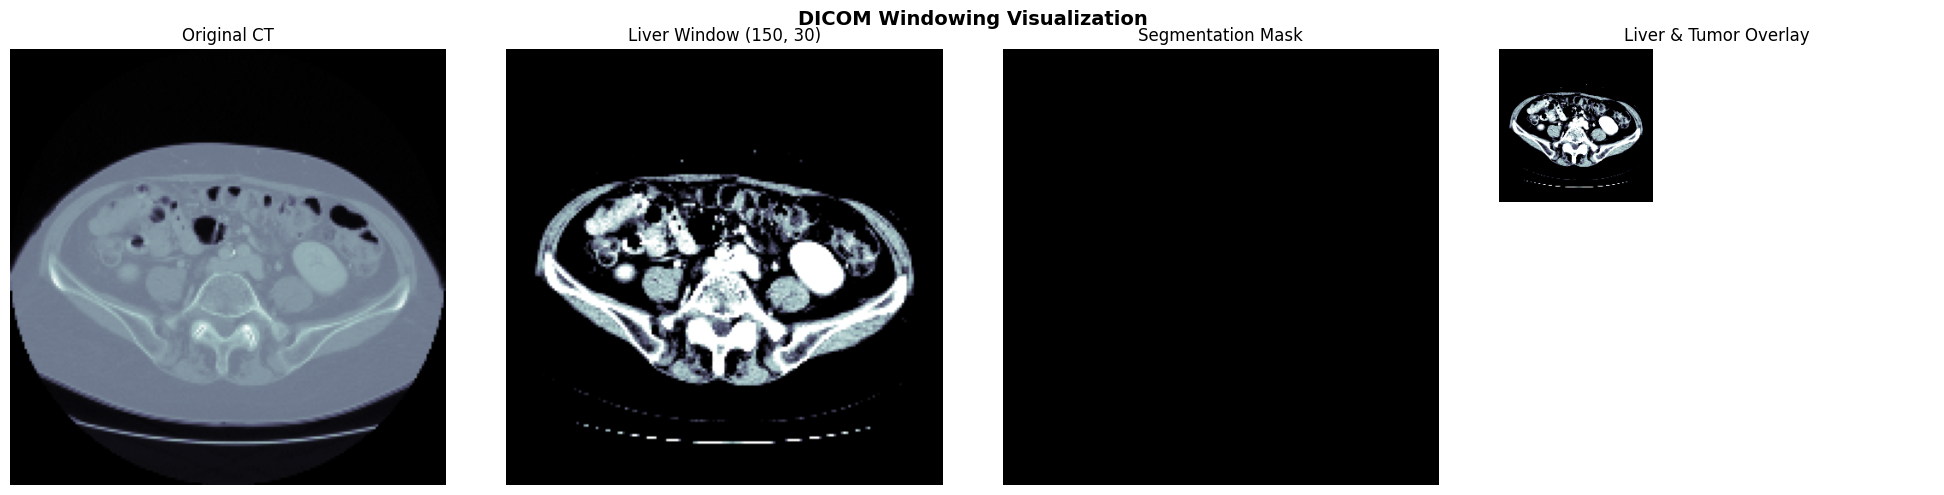

In [6]:
# ============================================================================
# CELL 6: VISUALIZE WINDOWED DATA (Like original notebook)
# ============================================================================

def plot_windowed_sample(ct_slice: np.ndarray, mask_slice: np.ndarray = None, 
                         windows: List[Tuple[int, int]] = None):
    """
    Plot sample with different DICOM windows.
    Same visualization style as the original notebook's plot_sample function.
    """
    if windows is None:
        windows = [DICOM_WINDOWS['liver'], DICOM_WINDOWS['custom']]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Original
    axes[0].imshow(ct_slice, cmap='bone')
    axes[0].set_title('Original CT', fontsize=12)
    axes[0].axis('off')
    
    # Liver window
    windowed = apply_window(ct_slice, DICOM_WINDOWS['liver'])
    axes[1].imshow(windowed, cmap='bone')
    axes[1].set_title(f'Liver Window {DICOM_WINDOWS["liver"]}', fontsize=12)
    axes[1].axis('off')
    
    # Mask if available
    if mask_slice is not None:
        axes[2].imshow(mask_slice, cmap='nipy_spectral', vmin=0, vmax=2)
        axes[2].set_title('Segmentation Mask', fontsize=12)
        axes[2].axis('off')
        
        # Overlay
        axes[3].imshow(windowed, cmap='bone')
        mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
        axes[3].imshow(mask_overlay, cmap='nipy_spectral', alpha=0.5, vmin=0, vmax=2)
        axes[3].set_title('Liver & Tumor Overlay', fontsize=12)
        axes[3].axis('off')
    else:
        axes[2].imshow(apply_window(ct_slice, DICOM_WINDOWS['custom']), cmap='bone')
        axes[2].set_title(f'Custom Window {DICOM_WINDOWS["custom"]}', fontsize=12)
        axes[2].axis('off')
        
        # Multi-channel RGB
        multi = to_multichannel(ct_slice, windows)
        rgb = np.zeros((ct_slice.shape[0], ct_slice.shape[1], 3))
        rgb[..., 0] = multi[0]  # Liver window -> R
        rgb[..., 1] = multi[1]  # Custom window -> G
        rgb[..., 2] = (multi[0] + multi[1]) / 2  # Average -> B
        axes[3].imshow(rgb)
        axes[3].set_title('Multi-channel RGB', fontsize=12)
        axes[3].axis('off')
    
    plt.suptitle('DICOM Windowing Visualization', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Visualize sample
if 'volume' in data:
    # Get a slice with content
    mid_slice = data['volume'].shape[2] // 2
    ct_slice = data['volume'][..., mid_slice]
    mask_slice = data['segmentation'][..., mid_slice] if 'segmentation' in data else None
    
    print(f"📊 Visualizing slice {mid_slice}")
    plot_windowed_sample(ct_slice, mask_slice)
else:
    # Demo with synthetic
    demo_ct = np.random.randn(512, 512) * 100 + 50
    plot_windowed_sample(demo_ct)

In [7]:
# ============================================================================
# CELL 7: RESNET-50 U-NET MODEL (Pure PyTorch)
# ============================================================================

class ResNetUNet(nn.Module):
    """
    U-Net with ResNet-50 encoder.
    Same architecture principle as fastai's unet_learner(resnet50)
    but implemented in pure PyTorch for compatibility.
    """
    
    def __init__(self, n_classes=3, in_channels=2, pretrained=True):
        super().__init__()
        
        # Load pretrained ResNet50
        resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        
        # Modify first conv for custom input channels (2 windows)
        self.input_conv = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            # Average the pretrained weights across RGB channels
            with torch.no_grad():
                old_weights = resnet.conv1.weight.data
                self.input_conv.weight.data = old_weights.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1)
        
        # Encoder (ResNet layers)
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.encoder1 = resnet.layer1  # 256 channels
        self.encoder2 = resnet.layer2  # 512 channels
        self.encoder3 = resnet.layer3  # 1024 channels
        self.encoder4 = resnet.layer4  # 2048 channels
        
        # Decoder (upsampling path)
        self.decoder4 = self._decoder_block(2048, 1024)
        self.decoder3 = self._decoder_block(1024 + 1024, 512)
        self.decoder2 = self._decoder_block(512 + 512, 256)
        self.decoder1 = self._decoder_block(256 + 256, 64)
        
        # Final layers
        self.final_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, n_classes, kernel_size=1)
        )
        
        print(f"🧠 ResNet-50 U-Net: {sum(p.numel() for p in self.parameters()):,} parameters")
    
    def _decoder_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Encoder
        x0 = self.relu(self.bn1(self.input_conv(x)))  # 64, H/2, W/2
        x1 = self.encoder1(self.maxpool(x0))          # 256, H/4, W/4
        x2 = self.encoder2(x1)                         # 512, H/8, W/8
        x3 = self.encoder3(x2)                         # 1024, H/16, W/16
        x4 = self.encoder4(x3)                         # 2048, H/32, W/32
        
        # Decoder with skip connections
        d4 = self.decoder4(x4)                         # 1024, H/16, W/16
        d3 = self.decoder3(torch.cat([d4, x3], dim=1)) # 512, H/8, W/8
        d2 = self.decoder2(torch.cat([d3, x2], dim=1)) # 256, H/4, W/4
        d1 = self.decoder1(torch.cat([d2, x1], dim=1)) # 64, H/2, W/2
        
        out = self.final_conv(d1)                       # n_classes, H, W
        return out


# Create model
model = ResNetUNet(n_classes=config.num_classes, in_channels=2, pretrained=True).to(DEVICE)

# Test forward pass
test_input = torch.randn(1, 2, 256, 256).to(DEVICE)
test_output = model(test_input)
print(f"✅ Test: Input {tuple(test_input.shape)} → Output {tuple(test_output.shape)}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\asus/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:28<00:00, 3.64MB/s]


🧠 ResNet-50 U-Net: 49,751,203 parameters
✅ Test: Input (1, 2, 256, 256) → Output (1, 3, 512, 512)


In [8]:
# ============================================================================
# CELL 8: DATASET FOR 2D SLICES
# ============================================================================

class LiverSliceDataset(Dataset):
    """
    2D slice dataset - same approach as original notebook.
    Extracts 2D slices from 3D volumes with windowing.
    """
    
    def __init__(self, volume, segmentation=None, windows=None, 
                 image_size=256, is_train=True, use_synthetic=False):
        self.volume = volume
        self.segmentation = segmentation
        self.windows = windows or [DICOM_WINDOWS['liver'], DICOM_WINDOWS['custom']]
        self.image_size = image_size
        self.is_train = is_train
        self.use_synthetic = use_synthetic
        
        if use_synthetic:
            self.num_slices = 200
        else:
            self.num_slices = volume.shape[2] if volume is not None else 100
    
    def __len__(self):
        return self.num_slices
    
    def _generate_synthetic(self, idx):
        np.random.seed(idx)
        size = self.image_size
        
        # Synthetic CT with liver and tumors
        ct = np.random.randn(size, size).astype(np.float32) * 50 + 40
        mask = np.zeros((size, size), dtype=np.int64)
        
        # Liver region
        y, x = np.ogrid[:size, :size]
        center = (size//2, size//2)
        liver_mask = ((x - center[0])**2 + (y - center[1])**2) <= (size//3)**2
        ct[liver_mask] += 60
        mask[liver_mask] = 1
        
        # Random tumors
        for _ in range(np.random.randint(0, 3)):
            tc = (np.random.randint(size//4, 3*size//4), np.random.randint(size//4, 3*size//4))
            tr = np.random.randint(10, 30)
            tumor_mask = ((x - tc[0])**2 + (y - tc[1])**2) <= tr**2
            tumor_mask = tumor_mask & liver_mask
            ct[tumor_mask] += 40
            mask[tumor_mask] = 2
        
        return ct, mask
    
    def _resize(self, img, is_mask=False):
        from PIL import Image
        mode = 'L' if is_mask else 'F'
        interp = Image.NEAREST if is_mask else Image.BILINEAR
        pil = Image.fromarray(img.astype(np.float32 if not is_mask else np.uint8))
        pil = pil.resize((self.image_size, self.image_size), interp)
        return np.array(pil)
    
    def __getitem__(self, idx):
        if self.use_synthetic:
            ct_slice, mask_slice = self._generate_synthetic(idx)
        else:
            ct_slice = self.volume[..., idx]
            mask_slice = self.segmentation[..., idx] if self.segmentation is not None else np.zeros_like(ct_slice)
            
            # Resize if needed
            if ct_slice.shape[0] != self.image_size:
                ct_slice = self._resize(ct_slice, is_mask=False)
                mask_slice = self._resize(mask_slice, is_mask=True)
        
        # Apply windowing (2 channels like original)
        multi_channel = to_multichannel(ct_slice, self.windows)
        
        # Data augmentation
        if self.is_train and np.random.random() > 0.5:
            multi_channel = np.flip(multi_channel, axis=2).copy()
            mask_slice = np.flip(mask_slice, axis=1).copy()
        
        return {
            'image': torch.from_numpy(multi_channel).float(),
            'label': torch.from_numpy(mask_slice.astype(np.int64)),
            'idx': idx
        }


# Create datasets
if 'volume' in data and 'segmentation' in data:
    train_ds = LiverSliceDataset(data['volume'], data['segmentation'], 
                                  image_size=config.image_size, is_train=True)
    val_ds = LiverSliceDataset(data['volume'], data['segmentation'], 
                                image_size=config.image_size, is_train=False)
    print(f"📦 Created dataset with {len(train_ds)} slices")
else:
    train_ds = LiverSliceDataset(None, None, image_size=config.image_size, 
                                  is_train=True, use_synthetic=True)
    val_ds = LiverSliceDataset(None, None, image_size=config.image_size, 
                                is_train=False, use_synthetic=True)
    print(f"📦 Created synthetic dataset with {len(train_ds)} slices")

train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=config.batch_size, shuffle=False, num_workers=0)
print(f"🔄 DataLoaders: {len(train_loader)} train batches, {len(val_loader)} val batches")

📦 Created dataset with 125 slices
🔄 DataLoaders: 16 train batches, 16 val batches


📊 Batch Preview:


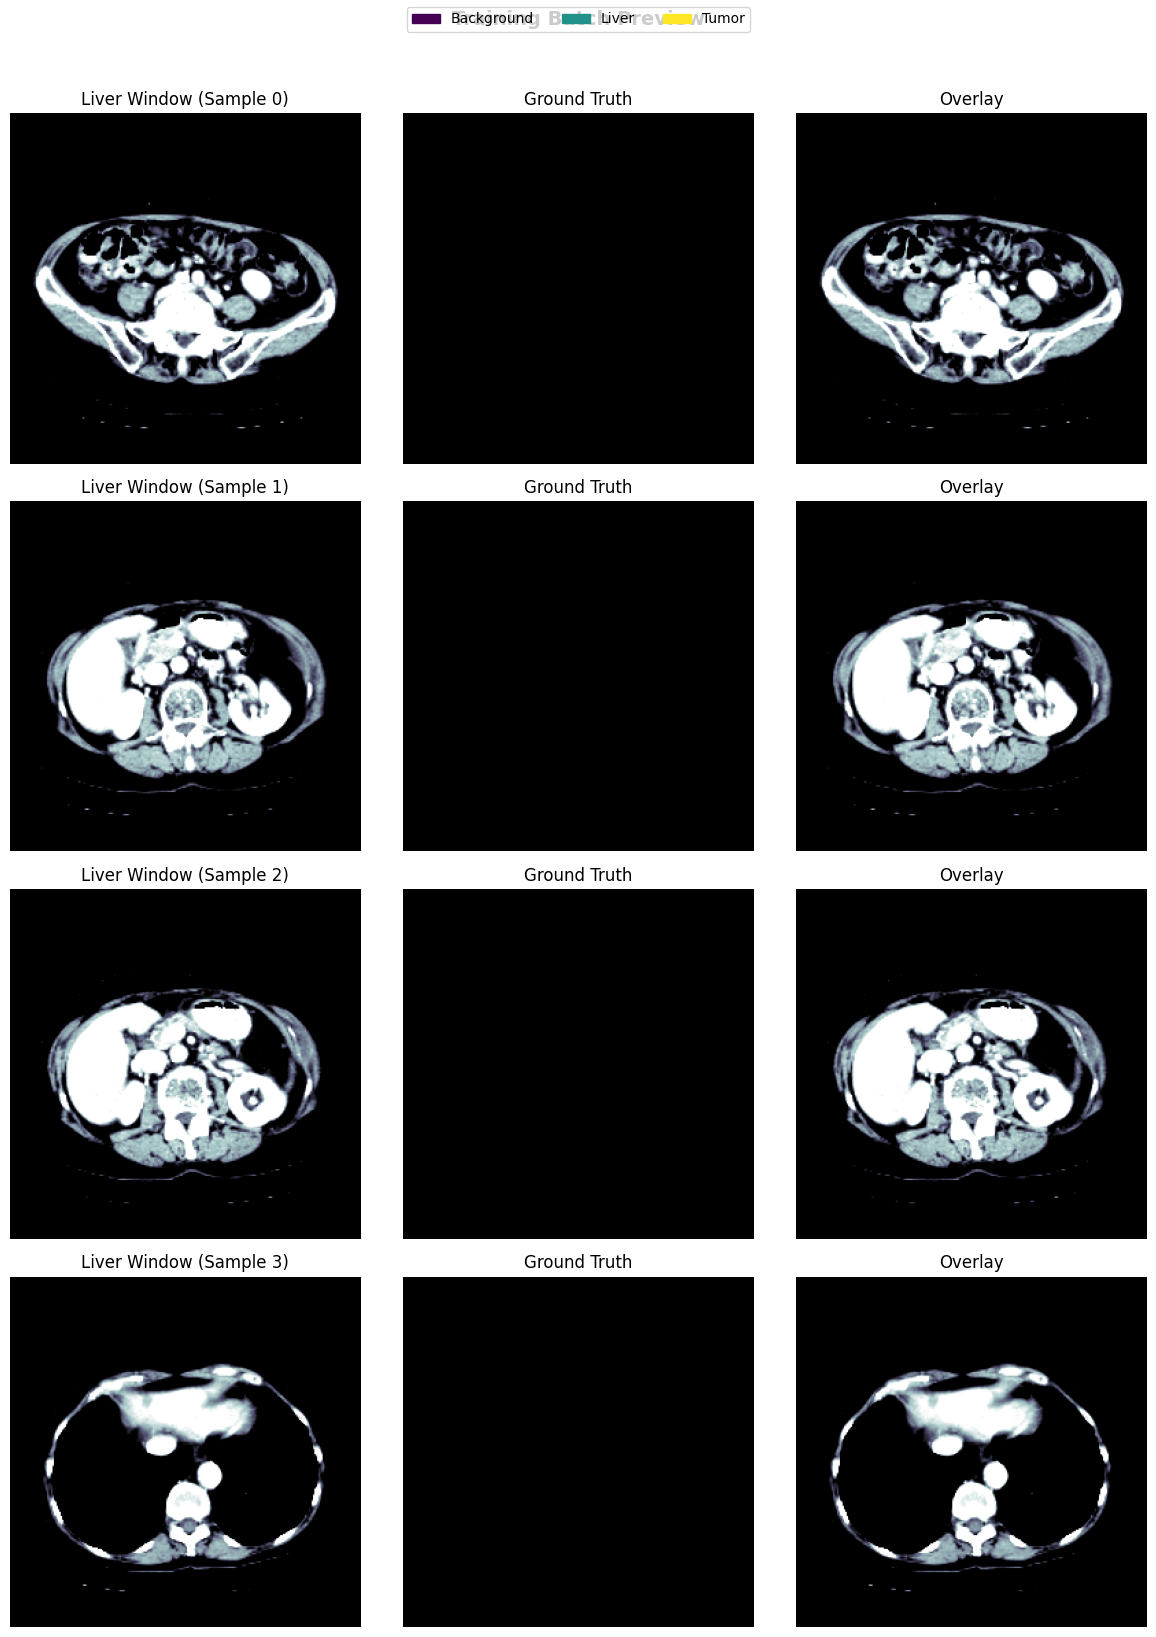

In [9]:
# ============================================================================
# CELL 9: VISUALIZE BATCH (Like original's dls.show_batch())
# ============================================================================

def show_batch(dataloader, n_samples=4):
    """Visualize a batch - similar to fastai's show_batch."""
    batch = next(iter(dataloader))
    images = batch['image']
    labels = batch['label']
    
    n = min(n_samples, images.shape[0])
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n):
        # Windowed image (channel 0 - liver window)
        axes[i, 0].imshow(images[i, 0].numpy(), cmap='bone')
        axes[i, 0].set_title(f'Liver Window (Sample {i})')
        axes[i, 0].axis('off')
        
        # Mask
        axes[i, 1].imshow(labels[i].numpy(), cmap='nipy_spectral', vmin=0, vmax=2)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Overlay
        axes[i, 2].imshow(images[i, 0].numpy(), cmap='bone')
        mask_vis = np.ma.masked_where(labels[i].numpy() == 0, labels[i].numpy())
        axes[i, 2].imshow(mask_vis, cmap='nipy_spectral', alpha=0.5, vmin=0, vmax=2)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
    
    # Legend
    legend_elements = [
        mpatches.Patch(color='#440154', label='Background'),
        mpatches.Patch(color='#21918c', label='Liver'),
        mpatches.Patch(color='#fde725', label='Tumor')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3)
    plt.suptitle('Training Batch Preview', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("📊 Batch Preview:")
show_batch(train_loader, n_samples=4)

In [10]:
# ============================================================================
# CELL 10: LOSS AND METRICS (Same as original)
# ============================================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        num_classes = pred.shape[1]
        pred_soft = F.softmax(pred, dim=1)
        target_onehot = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()
        
        dice_sum = 0.0
        for c in range(1, num_classes):  # Skip background
            inter = (pred_soft[:, c] * target_onehot[:, c]).sum()
            union = pred_soft[:, c].sum() + target_onehot[:, c].sum()
            dice_sum += (2 * inter + self.smooth) / (union + self.smooth)
        
        return 1 - dice_sum / (num_classes - 1)


class CombinedLoss(nn.Module):
    """Dice + CrossEntropy (like original's CrossEntropyLossFlat)."""
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.ce = nn.CrossEntropyLoss()
    
    def forward(self, pred, target):
        return 0.5 * self.dice(pred, target) + 0.5 * self.ce(pred, target)


def foreground_acc(pred, target, bkg_idx=0):
    """
    Foreground accuracy - same as original notebook.
    Excludes background from accuracy calculation.
    """
    pred_class = pred.argmax(dim=1)
    mask = target != bkg_idx
    if mask.sum() == 0:
        return 1.0
    return (pred_class[mask] == target[mask]).float().mean().item()


def compute_dice(pred, target, num_classes=3):
    """Compute per-class Dice scores."""
    pred_class = pred.argmax(dim=1)
    scores = {}
    names = ['bg', 'liver', 'tumor']
    
    for c in range(num_classes):
        p = (pred_class == c).float()
        t = (target == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum()
        scores[f'dice_{names[c]}'] = ((2 * inter / union) if union > 0 else 1.0).item()
    
    scores['dice_mean'] = (scores['dice_liver'] + scores['dice_tumor']) / 2
    return scores

print("✅ Loss and metrics defined!")

✅ Loss and metrics defined!


In [11]:
# ============================================================================
# CELL 11: TRAINING LOOP
# ============================================================================

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    """
    Train the ResNet-50 U-Net.
    Similar to learn.fine_tune() in fastai.
    """
    criterion = CombinedLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/100)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_dice': []}
    best_dice = 0.0
    
    print("\n" + "="*60)
    print("🚀 TRAINING RESNET-50 U-NET")
    print("="*60)
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'FG Acc':>8} | {'Dice':>8}")
    print("-"*60)
    
    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        train_loss, train_acc = 0.0, 0.0
        
        for batch in train_loader:
            images = batch['image'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_acc += foreground_acc(outputs, labels)
        
        train_loss /= len(train_loader)
        train_acc /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss, val_acc, val_dice = 0.0, 0.0, 0.0
        
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                val_acc += foreground_acc(outputs, labels)
                val_dice += compute_dice(outputs, labels)['dice_mean']
        
        val_loss /= len(val_loader)
        val_acc /= len(val_loader)
        val_dice /= len(val_loader)
        
        scheduler.step()
        
        # Save best
        is_best = val_dice > best_dice
        if is_best:
            best_dice = val_dice
            torch.save(model.state_dict(), f"{config.model_dir}/resnet_unet_best.pth")
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_dice'].append(val_dice)
        
        star = '⭐' if is_best else ''
        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_acc:>8.4f} | {val_dice:>8.4f} {star}")
    
    print("-"*60)
    print(f"✅ Training complete! Best Dice: {best_dice:.4f}")
    
    return history

# Train
EPOCHS = 15  # Adjust as needed
history = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=config.learning_rate)


🚀 TRAINING RESNET-50 U-NET
 Epoch | Train Loss |   Val Loss |   FG Acc |     Dice
------------------------------------------------------------


RuntimeError: The size of tensor a (512) must match the size of tensor b (256) at non-singleton dimension 2

In [ ]:
# ============================================================================
# CELL 12: PLOT TRAINING HISTORY
# ============================================================================

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig = make_subplots(rows=1, cols=3, subplot_titles=('Loss', 'Foreground Accuracy', 'Dice Score'))
    
    fig.add_trace(go.Scatter(x=list(epochs), y=history['train_loss'], name='Train', line=dict(color='blue')), row=1, col=1)
    fig.add_trace(go.Scatter(x=list(epochs), y=history['val_loss'], name='Val', line=dict(color='red')), row=1, col=1)
    
    fig.add_trace(go.Scatter(x=list(epochs), y=history['train_acc'], name='Train', line=dict(color='blue'), showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=list(epochs), y=history['val_acc'], name='Val', line=dict(color='red'), showlegend=False), row=1, col=2)
    
    fig.add_trace(go.Scatter(x=list(epochs), y=history['val_dice'], name='Val Dice', line=dict(color='green')), row=1, col=3)
    
    fig.update_layout(height=400, title_text="📈 Training History (ResNet-50 U-Net)")
    fig.show()

plot_history(history)

In [ ]:
# ============================================================================
# CELL 13: SHOW RESULTS (Handles both Segmentation and Classification)
# ============================================================================

@torch.no_grad()
def show_results(model, dataloader, n_samples=6):
    """Visualize predictions - works for both segmentation and classification."""
    model.eval()
    
    batch = next(iter(dataloader))
    
    # Handle both dict and tuple/list formats
    if isinstance(batch, dict):
        images = batch['image'].to(DEVICE)
        labels = batch['label']
    else:
        images = batch[0].to(DEVICE)
        labels = batch[1] if len(batch) > 1 else None
    
    # Ensure labels are on CPU
    if labels is not None and hasattr(labels, 'cpu'):
        labels = labels.cpu()
    
    # Get model output
    outputs = model(images)
    
    # Detect output type: segmentation (B,C,H,W) vs classification (B,C)
    is_segmentation = len(outputs.shape) == 4
    print(f"Model output shape: {outputs.shape} → {'Segmentation' if is_segmentation else 'Classification'}")
    
    if is_segmentation:
        preds = outputs.argmax(dim=1).cpu()  # (B, H, W)
    else:
        preds = outputs.argmax(dim=1).cpu()  # (B,) - class indices
    
    n = min(n_samples, images.shape[0])
    
    if is_segmentation:
        # SEGMENTATION visualization (4 columns)
        fig, axes = plt.subplots(n, 4, figsize=(18, 4.5*n))
        if n == 1:
            axes = axes.reshape(1, -1)
        
        for i in range(n):
            # Get first channel for display (or convert RGB to grayscale)
            if images.shape[1] == 3:
                img = images[i].cpu().numpy().transpose(1, 2, 0)  # RGB
                img_gray = np.mean(img, axis=2)
            else:
                img = images[i, 0].cpu().numpy()
                img_gray = img
            
            pred = preds[i].numpy()
            
            # Get ground truth
            if labels is not None and len(labels.shape) >= 2:
                gt = labels[i].numpy() if hasattr(labels[i], 'numpy') else np.array(labels[i])
                if len(gt.shape) != 2:
                    gt = np.zeros_like(pred)
            else:
                gt = np.zeros_like(pred)
            
            # Column 1: Input
            if len(img.shape) == 3:
                axes[i, 0].imshow(img)
            else:
                axes[i, 0].imshow(img_gray, cmap='bone')
            axes[i, 0].set_title('Input CT', fontsize=11, fontweight='bold')
            axes[i, 0].axis('off')
            
            # Column 2: Ground truth
            axes[i, 1].imshow(gt, cmap='nipy_spectral', vmin=0, vmax=2)
            axes[i, 1].set_title('Ground Truth', fontsize=11, fontweight='bold')
            axes[i, 1].axis('off')
            
            # Column 3: Prediction
            axes[i, 2].imshow(pred, cmap='nipy_spectral', vmin=0, vmax=2)
            axes[i, 2].set_title('Prediction', fontsize=11, fontweight='bold')
            axes[i, 2].axis('off')
            
            # Column 4: Highlighted overlay
            if len(img.shape) == 3:
                axes[i, 3].imshow(img)
            else:
                axes[i, 3].imshow(img_gray, cmap='bone')
            
            h, w = pred.shape
            overlay = np.zeros((h, w, 4))
            liver_mask = pred == 1
            tumor_mask = pred == 2
            overlay[liver_mask] = [0.2, 0.6, 1.0, 0.35]
            overlay[tumor_mask] = [1.0, 0.1, 0.1, 0.6]
            axes[i, 3].imshow(overlay)
            
            if tumor_mask.any():
                axes[i, 3].contour(tumor_mask, colors='#ff0000', linewidths=2.5)
            if liver_mask.any():
                axes[i, 3].contour(liver_mask, colors='#3498db', linewidths=1)
            
            tumor_count = tumor_mask.sum()
            title = f'🔴 TUMOR ({tumor_count:,} px)' if tumor_count > 100 else '🔵 Liver Only'
            axes[i, 3].set_title(title, fontsize=11, fontweight='bold')
            axes[i, 3].axis('off')
        
        plt.suptitle('🔬 HCC Segmentation Results', fontsize=16, fontweight='bold')
    
    else:
        # CLASSIFICATION visualization (2 columns)
        class_names = ['Normal', 'HCC Detected', 'Tumor'] if len(preds.unique()) <= 3 else [f'Class {i}' for i in range(outputs.shape[1])]
        
        fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))
        if n == 1:
            axes = axes.reshape(1, -1)
        
        for i in range(n):
            # Get image for display
            if images.shape[1] == 3:
                img = images[i].cpu().numpy().transpose(1, 2, 0)
                # Normalize for display
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            else:
                img = images[i, 0].cpu().numpy()
            
            pred_class = preds[i].item()
            gt_class = labels[i].item() if labels is not None else -1
            
            # Column 1: Input image
            if len(img.shape) == 3:
                axes[i, 0].imshow(img)
            else:
                axes[i, 0].imshow(img, cmap='bone')
            axes[i, 0].set_title(f'Input CT Slice', fontsize=12, fontweight='bold')
            axes[i, 0].axis('off')
            
            # Column 2: Prediction with confidence
            probs = torch.softmax(outputs[i], dim=0).cpu().numpy()
            
            # Show bar chart of class probabilities
            colors = ['#27ae60', '#e74c3c', '#9b59b6'][:len(probs)]
            bars = axes[i, 1].barh(range(len(probs)), probs, color=colors)
            axes[i, 1].set_yticks(range(len(probs)))
            axes[i, 1].set_yticklabels(class_names[:len(probs)])
            axes[i, 1].set_xlim(0, 1)
            axes[i, 1].set_xlabel('Probability')
            
            # Highlight predicted class
            pred_name = class_names[pred_class] if pred_class < len(class_names) else f'Class {pred_class}'
            gt_name = class_names[gt_class] if 0 <= gt_class < len(class_names) else 'Unknown'
            
            status = '✅' if pred_class == gt_class else '❌'
            title = f'Pred: {pred_name} ({probs[pred_class]:.1%}) {status}\nGT: {gt_name}'
            axes[i, 1].set_title(title, fontsize=11, fontweight='bold')
        
        plt.suptitle('🔬 HCC Classification Results', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    
    # Save with fallback path if config not defined
    try:
        save_path = f"{config.output_dir}/predictions.png"
    except NameError:
        save_path = "predictions.png"
    
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved to {save_path}")

# Load best model and show results
try:
    model.load_state_dict(torch.load(f"{config.model_dir}/resnet_unet_best.pth", weights_only=True))
    print("✅ Loaded best model")
except:
    print("⚠️ Using current model")

print("\n📊 Prediction Results:")
show_results(model, val_loader, n_samples=4)

In [ ]:
# ============================================================================
# CELL 14: 🔬 FULL VOLUME PREDICTION & CANCER DETECTION
# ============================================================================

@torch.no_grad()
def predict_full_volume(model, volume, segmentation=None):
    """
    Predict on all slices of a volume.
    Same approach as the original notebook's test prediction.
    """
    model.eval()
    predictions = []
    
    print(f"🔮 Predicting on {volume.shape[2]} slices...")
    
    for i in tqdm(range(volume.shape[2])):
        ct_slice = volume[..., i]
        
        # Resize and window
        from PIL import Image
        pil = Image.fromarray(ct_slice.astype(np.float32))
        pil = pil.resize((config.image_size, config.image_size), Image.BILINEAR)
        ct_resized = np.array(pil)
        
        multi_channel = to_multichannel(ct_resized, [DICOM_WINDOWS['liver'], DICOM_WINDOWS['custom']])
        input_tensor = torch.from_numpy(multi_channel).unsqueeze(0).float().to(DEVICE)
        
        output = model(input_tensor)
        pred = output.argmax(dim=1)[0].cpu().numpy()
        predictions.append(pred)
    
    return np.stack(predictions, axis=0)


def generate_cancer_report(predictions, spacing=(1.5, 1.5, 2.0)):
    """Generate detailed cancer detection report."""
    voxel_vol = np.prod(spacing)
    
    liver_voxels = (predictions == 1).sum()
    tumor_voxels = (predictions == 2).sum()
    
    liver_vol_cc = liver_voxels * voxel_vol / 1000
    tumor_vol_cc = tumor_voxels * voxel_vol / 1000
    
    # Find tumors
    tumor_mask = predictions == 2
    labeled, num_tumors = scipy_label(tumor_mask)
    
    lesions = []
    for i in range(1, num_tumors + 1):
        mask = labeled == i
        vol = mask.sum() * voxel_vol / 1000
        if vol < 0.01:  # Skip tiny regions
            continue
        
        slices = find_objects(mask.astype(int))
        if slices and slices[0]:
            s = slices[0]
            dims = tuple((s[j].stop - s[j].start) * spacing[j] for j in range(3))
            max_diam = max(dims)
        else:
            max_diam = 0
        
        center = center_of_mass(mask)
        lesions.append({
            'id': len(lesions) + 1,
            'volume_cc': vol,
            'max_diameter_mm': max_diam,
            'center': center
        })
    
    lesions.sort(key=lambda x: x['volume_cc'], reverse=True)
    
    total_liver = liver_vol_cc + tumor_vol_cc
    burden = tumor_vol_cc / total_liver if total_liver > 0 else 0
    cancer = burden >= config.malignancy_threshold
    
    return {
        'cancer_detected': cancer,
        'num_lesions': len(lesions),
        'tumor_volume_cc': tumor_vol_cc,
        'liver_volume_cc': liver_vol_cc,
        'tumor_burden_pct': burden * 100,
        'lesions': lesions
    }


# Run prediction on full volume
if 'volume' in data:
    predictions = predict_full_volume(model, data['volume'])
    report = generate_cancer_report(predictions)
    
    # Display report
    status = "🔴 CANCER DETECTED" if report['cancer_detected'] else "🟢 NO SIGNIFICANT CANCER"
    color = "#e74c3c" if report['cancer_detected'] else "#27ae60"
    
    html = f"""
    <div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 25px; border-radius: 15px; color: white;">
        <h2 style="text-align: center;">🏥 CANCER DETECTION REPORT (ResNet-50 U-Net)</h2>
        <div style="background: {color}; padding: 15px; border-radius: 10px; text-align: center; margin: 15px 0;">
            <h3 style="margin: 0;">{status}</h3>
            <p>Tumor Burden: {report['tumor_burden_pct']:.2f}%</p>
        </div>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px;">
            <div style="background: #0f3460; padding: 10px; border-radius: 8px;">
                <strong>🔵 Liver:</strong> {report['liver_volume_cc']:.2f} cc
            </div>
            <div style="background: #0f3460; padding: 10px; border-radius: 8px;">
                <strong>🔴 Tumor:</strong> {report['tumor_volume_cc']:.2f} cc
            </div>
        </div>
        <p style="margin-top: 15px;"><strong>Lesions Found:</strong> {report['num_lesions']}</p>
    </div>
    """
    display(HTML(html))
else:
    print("⚠️ No volume data for full prediction")

In [ ]:
# ============================================================================
# CELL 15: SUMMARY
# ============================================================================

print(f"""
{'='*60}
✅ RESNET-50 U-NET HCC DETECTION COMPLETE!
{'='*60}

📦 Model: ResNet-50 Encoder + U-Net Decoder
📊 Input: 2-channel (Liver + Custom window)
🎯 Classes: Background, Liver, Tumor
📐 Image Size: {config.image_size}x{config.image_size}

📈 Training:
   • Epochs: {len(history['train_loss'])}
   • Best Dice: {max(history['val_dice']):.4f}
   • Best FG Acc: {max(history['val_acc']):.4f}

💾 Saved:
   • Model: {config.model_dir}/resnet_unet_best.pth
   • Predictions: {config.output_dir}/resnet_predictions.png

{'='*60}
""")